# Computing the Reeb graph of a filtered simplicial complex

This notebook gives a tutorial to computing the Reeb graph from a filtered simplicial complex. We assume that this complex is given as the `LowerStar` class (see [LowerStar documentation](../modules/reeb/lowerstar.rst) for details). 

In [26]:
from cereeberus import LowerStar, ReebGraph, computeReeb


## Simple example
Consider the following simplicial complex with height function. 

<img src="../images/SmallComplexExample.jpeg" alt="Small Complex Example" style="width:200px;">

First, we construct this simplicial complex with a lower star filtration, were we need only specify the top dimensional simplices. Note that the `LowerStar` class is built on gudhi's `SimplexTree`, so it retains all of that class' functionality. 

In [27]:
K = LowerStar()
K.insert([0, 1, 2])
K.insert([1, 3])
K.insert([2,3])
K.insert([0,4])
K.assign_filtration([0], 0.0)
K.assign_filtration([1], 3.0)
K.assign_filtration([2], 5.0)
K.assign_filtration([3], 7)
K.assign_filtration([4], 9.0)


Then computing the Reeb graph of this complex is as easy as the following. By default, the Reeb graph only has nodes where the topology of the level sets changes: minima, maxima, and the points where components merge or split. Here the minimum at height 0 has two edges going up: one to the maximum at height 9 (vertex 4), and one to a split at height 3. The two edges from the split meet again at height 7, forming a loop. (`cpx` controls how far apart parallel edges are drawn.)

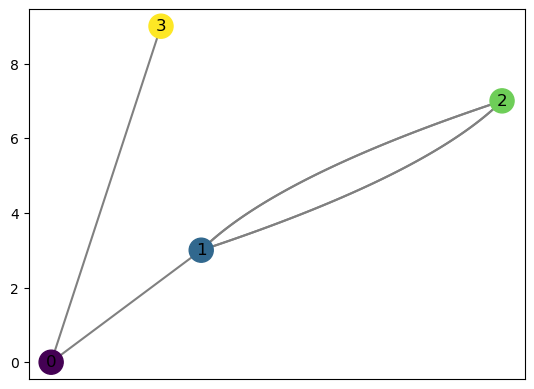

In [28]:
R = computeReeb(K)
R.draw(cpx=1)


### Keeping the regular nodes

Nodes with exactly one edge coming in from below and one going out above are *regular*: the level set does not change there, so they are not needed to describe the Reeb graph. They are left out by default. To keep a node for every level-set component at every vertex height, with a midpoint node (named `e_0`, `e_1`, ...) on each edge in between, pass `keep_regular_nodes=True`. This is the output format of cereeberus 0.1.20 and earlier.

Both graphs describe the same Reeb graph; the second one just subdivides its edges.

default: 4 nodes, 4 edges
keep_regular_nodes: 18 nodes, 18 edges


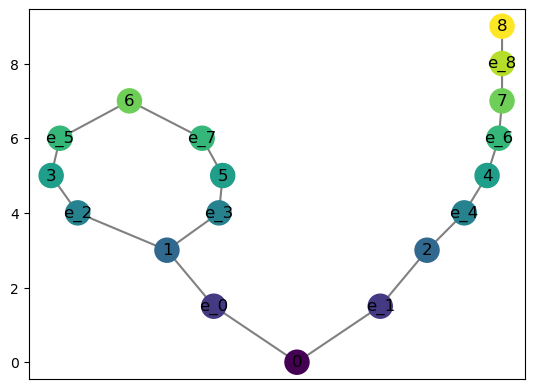

In [29]:
R_full = computeReeb(K, keep_regular_nodes=True)
print('default:', R.number_of_nodes(), 'nodes,', R.number_of_edges(), 'edges')
print('keep_regular_nodes:', R_full.number_of_nodes(), 'nodes,', R_full.number_of_edges(), 'edges')
R_full.draw()


Going the other way, `remove_all_regular_vertices` removes the regular nodes from a graph that has them, which recovers the default output.

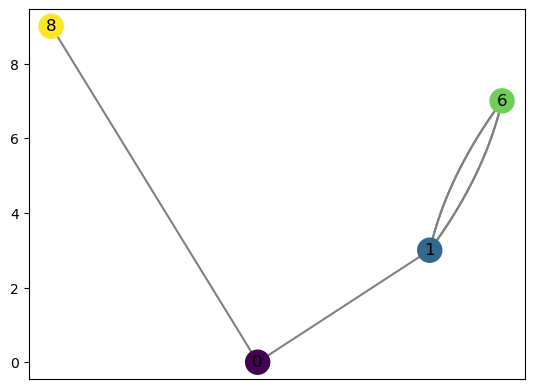

In [30]:
R_full.remove_all_regular_vertices()
R_full.draw()


## Torus example 

For a slightly more complex example, we have the following Torus example generator. 

In [31]:
from cereeberus.data import Torus


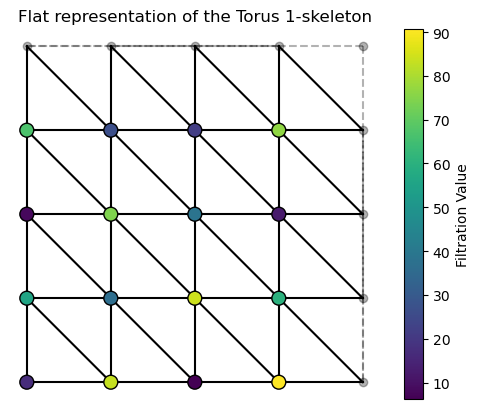

In [32]:
T = Torus()
T.generate_grid(grid_size = 4)
T.assign_random_values(0,100, seed=1986)
T.draw()


In [33]:
R = computeReeb(T)


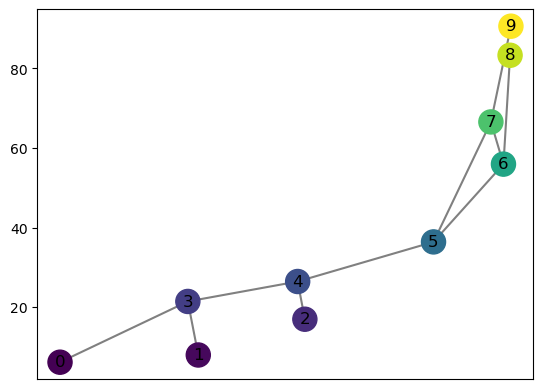

In [34]:
R.draw(cpx = 2)


## Degenerate (horizontal) edges

Here we check an example where there might be a horizontal edge in the input filtered simplicial complex which should end up being collapsed in the resulting Reeb graph. 

In [35]:
K = LowerStar()
K.insert([0,1])
K.insert([0,2])
K.insert([1,2])
K.insert([1,3])
K.insert([2,3])
K.assign_filtration([0], 5.0)
K.assign_filtration([1], 6.0)
K.assign_filtration([2], 6.0)
K.assign_filtration([3], 7)


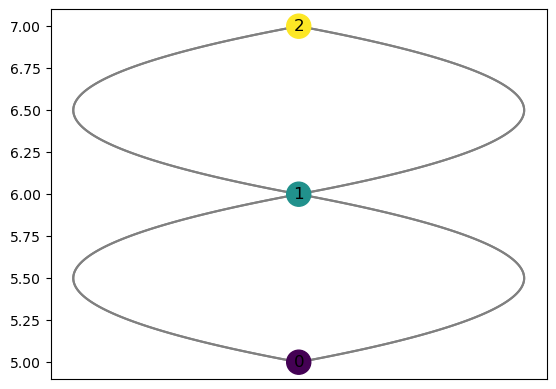

In [36]:
R = computeReeb(K)
R.draw()


## Higher-dimensional complexes

`computeReeb` works for complexes of any dimension. As an example, a solid tetrahedron with a height function has a Reeb graph that is a single edge, because every level set is connected.

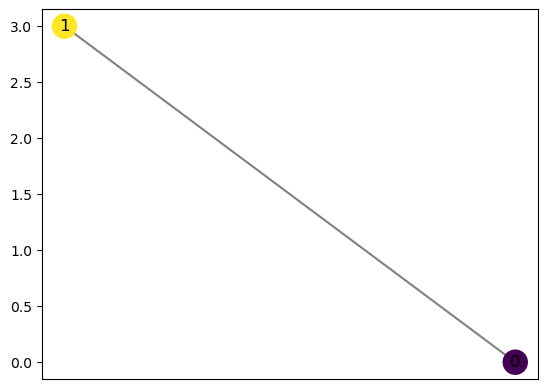

In [37]:
K = LowerStar()
K.insert([0, 1, 2, 3])
for v, height in enumerate([0.0, 1.0, 2.0, 3.0]):
    K.assign_filtration([v], height)

R = computeReeb(K)
R.draw()


Only the vertices, edges and triangles are needed to compute a Reeb graph, so the higher-dimensional simplices do not slow down the computation.

## Large complexes

For large complexes, such as surface meshes with many thousands of vertices, a few options can help:

- `set_pos=False` skips computing a drawing layout. Call `R.set_pos_from_f()` later if you want to draw the graph.
- `validate=False` skips checking that the filtration of every simplex is the maximum of its vertex values. `LowerStar` maintains this automatically, so the check can be skipped for complexes built with `assign_filtration`.
- `verbose=True` prints progress as the computation sweeps through the vertex heights.

```python
R = computeReeb(K, set_pos=False, validate=False, verbose=True)
```